In [ ]:
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display  # noqa: A004
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [ ]:

customers_df = pd.read_csv("3.csv")
customers_df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Share_Fruits,Share_Meat,Share_Fish,Share_Sweet,Share_Gold,AcceptedCampaignsTotal,Customer_For_Months,Customer_For_Months_Capped,PurchaseFrequencyMonthly,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0.054422,0.337662,0.106370,0.054422,0.054422,1,21.813403,21.813403,1.146084,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0.037037,0.222222,0.074074,0.037037,0.222222,0,3.745072,3.745072,1.602105,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0.063144,0.163660,0.143041,0.027062,0.054124,0,10.282523,10.282523,2.042300,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0.075472,0.377358,0.188679,0.056604,0.094340,0,4.599212,4.599212,1.739429,2
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0.101896,0.279621,0.109005,0.063981,0.035545,0,5.321945,5.321945,3.570123,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0.032066,0.135720,0.031320,0.087994,0.184191,0,12.549277,12.549277,1.434346,0
2208,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0.000000,0.067568,0.000000,0.000000,0.018018,1,0.657030,1.000000,22.000000,1
2209,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0.038678,0.174859,0.025786,0.009670,0.019339,1,5.124836,5.124836,3.707436,0
2210,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0.035587,0.253855,0.094899,0.035587,0.072361,0,5.157687,5.157687,4.459363,0


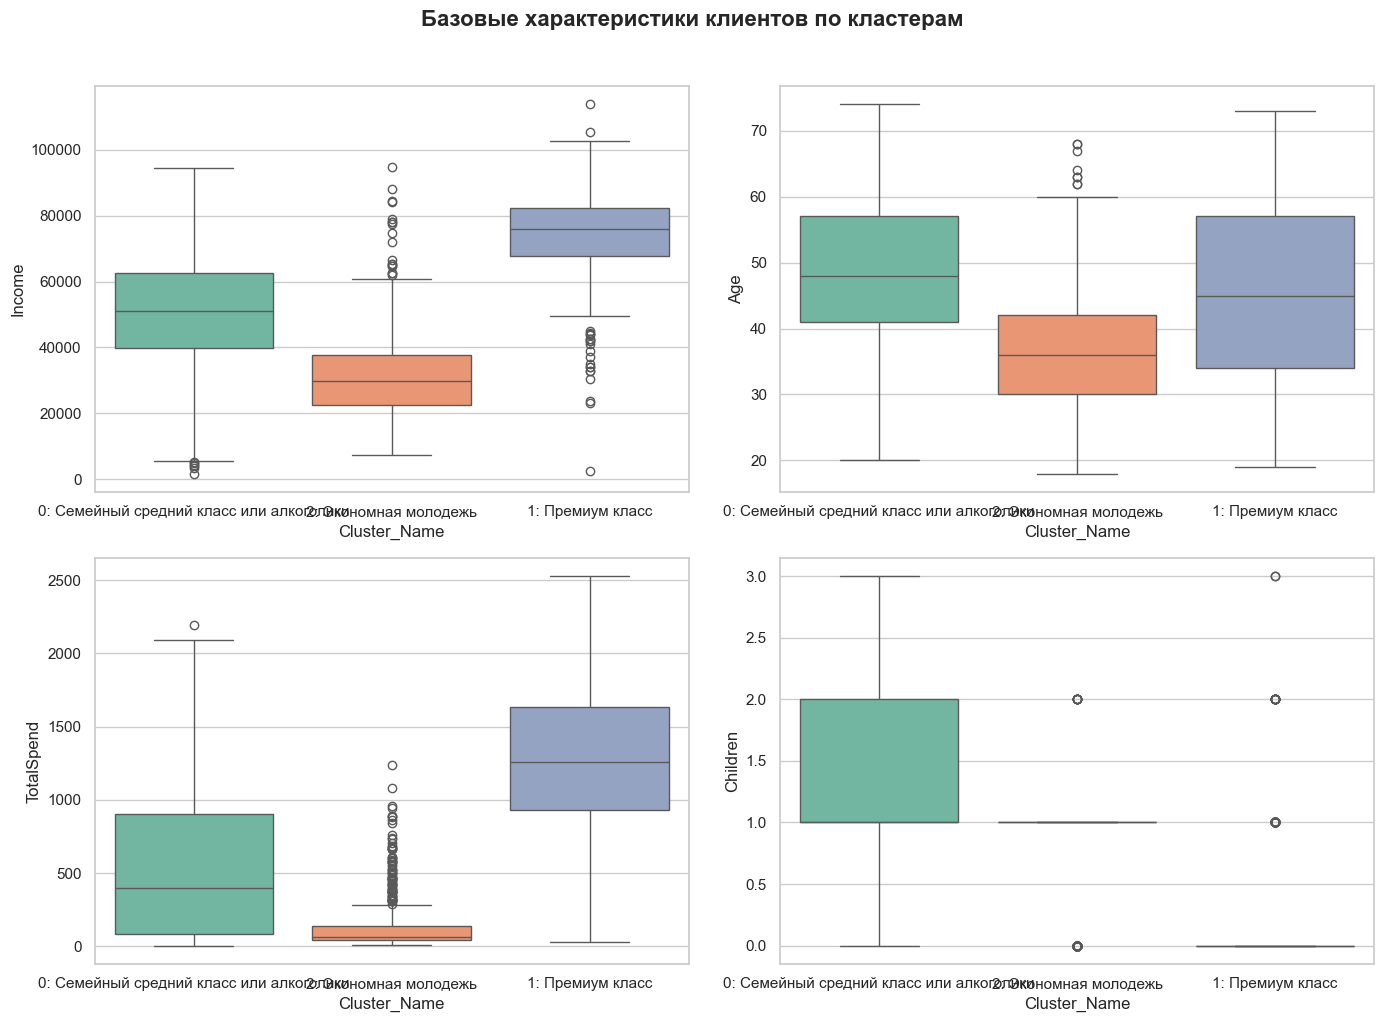

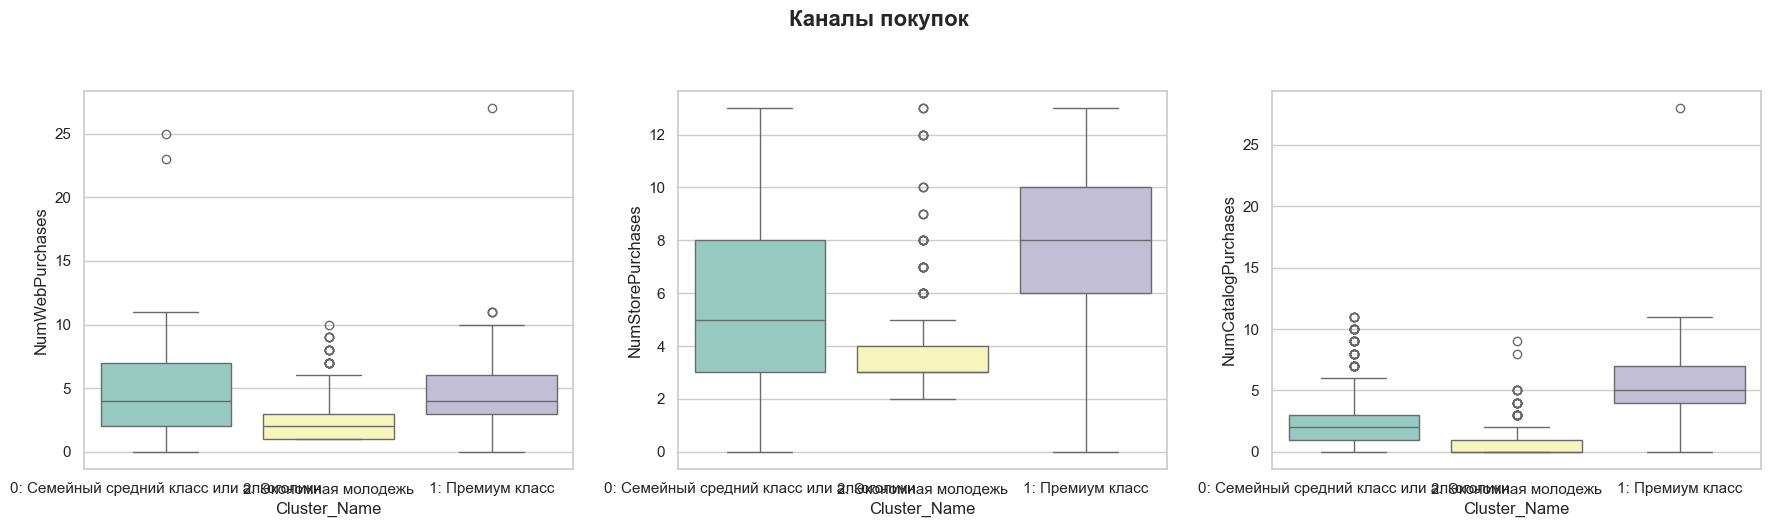

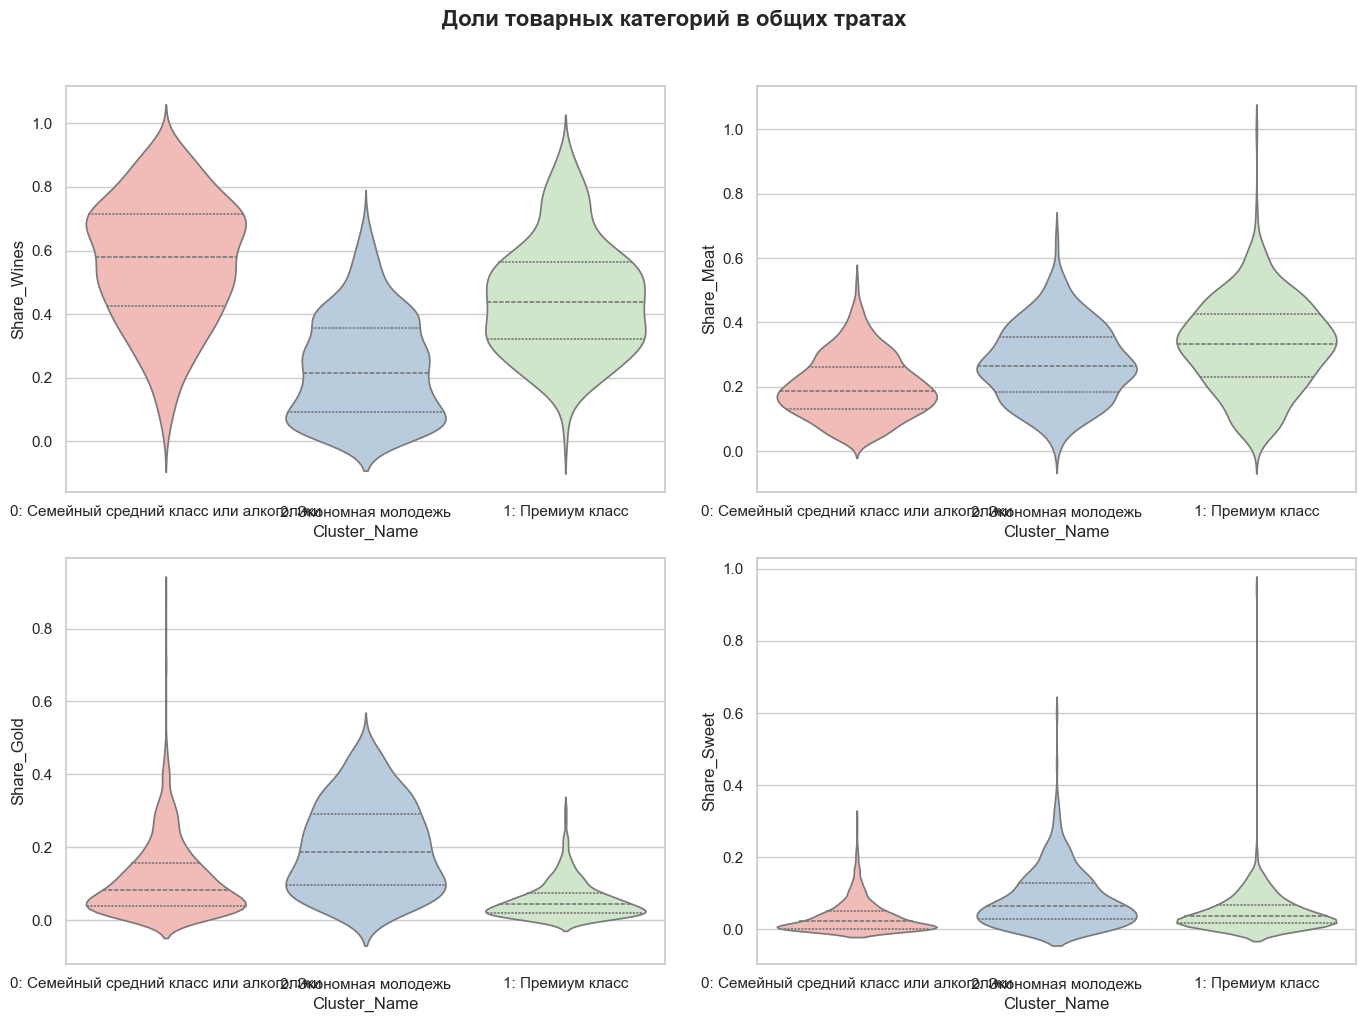

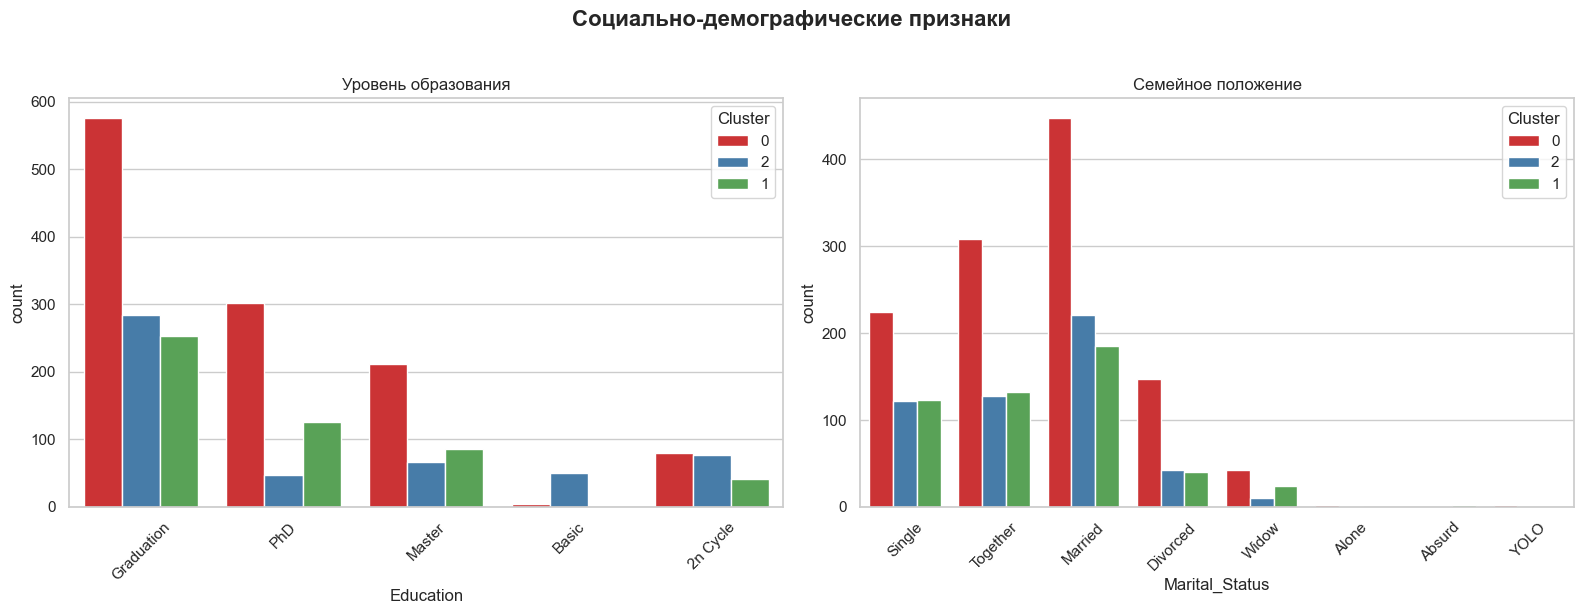

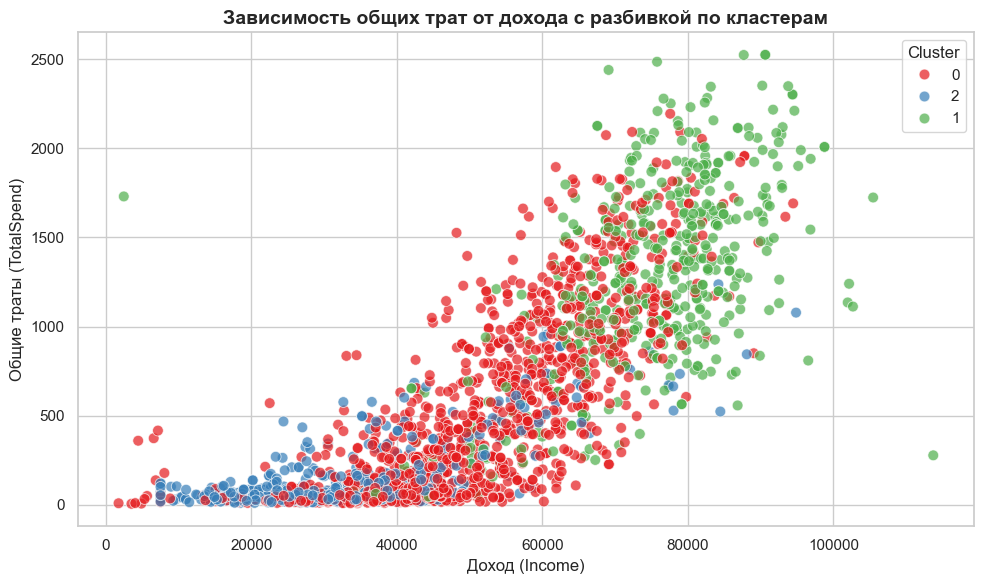

In [29]:




cluster_labels = {
    0: "0: Семейный средний класс или алкоголики",
    1: "1: Премиум класс",
    2: "2: Экономная молодежь"
}

customers_df['Cluster_Name'] = customers_df['Cluster'].map(cluster_labels)

sns.set_theme(style="whitegrid", palette="muted")

plot_df = customers_df.copy()
plot_df["Cluster"] = plot_df["Cluster"].astype(str)

if "Income" in plot_df.columns:
    plot_df = plot_df[plot_df["Income"] < 150000]  # noqa: PLR2004

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=plot_df, x="Cluster_Name", y="Income", hue="Cluster", ax=axes[0, 0], palette="Set2", legend=False)
sns.boxplot(data=plot_df, x="Cluster_Name", y="Age", hue="Cluster", ax=axes[0, 1], palette="Set2", legend=False)
sns.boxplot(data=plot_df, x="Cluster_Name", y="TotalSpend", hue="Cluster", ax=axes[1, 0], palette="Set2", legend=False)
sns.boxplot(data=plot_df, x="Cluster_Name", y="Children", hue="Cluster", ax=axes[1, 1], palette="Set2", legend=False)
plt.suptitle("Базовые характеристики клиентов по кластерам", fontsize=16, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=plot_df, x="Cluster_Name", y="NumWebPurchases", hue="Cluster", ax=axes[0], palette="Set3", legend=False)
sns.boxplot(data=plot_df, x="Cluster_Name", y="NumStorePurchases", hue="Cluster", ax=axes[1], palette="Set3", legend=False)
sns.boxplot(data=plot_df, x="Cluster_Name", y="NumCatalogPurchases", hue="Cluster", ax=axes[2], palette="Set3", legend=False)
plt.suptitle("Каналы покупок", fontsize=16, y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.violinplot(
    data=plot_df,
    x="Cluster_Name",
    y="Share_Wines",
    hue="Cluster",
    ax=axes[0, 0],
    palette="Pastel1",
    inner="quartile",
    legend=False,
)
sns.violinplot(
    data=plot_df,
    x="Cluster_Name",
    y="Share_Meat",
    hue="Cluster",
    ax=axes[0, 1],
    palette="Pastel1",
    inner="quartile",
    legend=False,
)
sns.violinplot(
    data=plot_df,
    x="Cluster_Name",
    y="Share_Gold",
    hue="Cluster",
    ax=axes[1, 0],
    palette="Pastel1",
    inner="quartile",
    legend=False,
)
sns.violinplot(
    data=plot_df,
    x="Cluster_Name",
    y="Share_Sweet",
    hue="Cluster",
    ax=axes[1, 1],
    palette="Pastel1",
    inner="quartile",
    legend=False,
)
plt.suptitle("Доли товарных категорий в общих тратах", fontsize=16, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=plot_df, x="Education", hue="Cluster", ax=axes[0], palette="Set1")
axes[0].set_title("Уровень образования")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=plot_df, x="Marital_Status", hue="Cluster", ax=axes[1], palette="Set1")
axes[1].set_title("Семейное положение")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Социально-демографические признаки", fontsize=16, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="Income", y="TotalSpend", hue="Cluster", palette="Set1", alpha=0.7, s=60)
plt.title("Зависимость общих трат от дохода с разбивкой по кластерам", fontsize=14, fontweight="bold")
plt.xlabel("Доход (Income)")
plt.ylabel("Общие траты (TotalSpend)")
plt.tight_layout()
plt.show()

sns.reset_orig()

In [ ]:


features_matrix = [
    "Age",
    "Children",
    "Recency",
    "TotalSpendToIncome",
    "PurchaseFrequencyMonthly",
    "NumWebVisitsMonth",
    "WebPurchaseShare",
    "StorePurchaseShare",
    "Share_Wines",
    "Share_Meat",
]

target = "Cluster"

In [ ]:


customers_df = customers_df.drop_duplicates()

needed_columns = [*features_matrix, target]

for col in needed_columns:
    customers_df[col] = pd.to_numeric(customers_df[col], errors="coerce")

customers_df = customers_df.dropna(subset=needed_columns)

customers_df[target] = customers_df[target].astype(int)

print("Размер после обработки:", customers_df.shape)
print("Распределение классов:")
print(customers_df[target].value_counts().sort_index())

print("\nДоли классов:")
print(customers_df[target].value_counts(normalize=True).sort_index())

Размер после обработки: (2212, 54)
Распределение классов:
Cluster
0    1178
1     509
2     525
Name: count, dtype: int64

Доли классов:
Cluster
0    0.532550
1    0.230108
2    0.237342
Name: proportion, dtype: float64


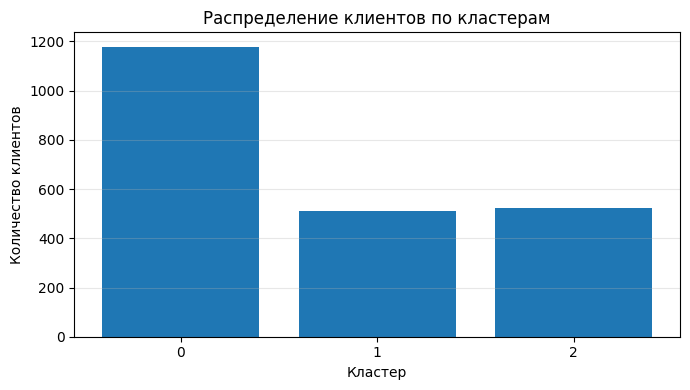

In [ ]:


class_counts = customers_df[target].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.to_numpy())
plt.title("Распределение клиентов по кластерам")
plt.xlabel("Кластер")
plt.ylabel("Количество клиентов")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cluster_balance.png", dpi=300)
plt.show()

In [ ]:


X_cls = customers_df[features_matrix]
y_multi = customers_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi,
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1769, 10)
Размер тестовой выборки: (443, 10)


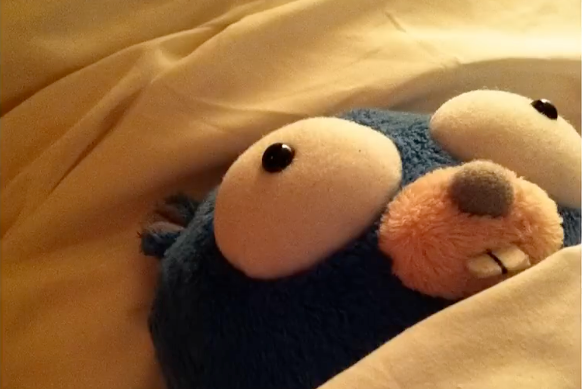

In [ ]:


models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ],
    ),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))]),
    "Decision Tree": Pipeline(
        [("model", DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42))],
    ),
    "Random Forest": Pipeline(
        [("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42))],
    ),
    "Gradient Boosting": Pipeline([("model", GradientBoostingClassifier(random_state=42))]),
    "Stacking Ensemble": StackingClassifier(
        estimators=[
            (
                "logreg",
                Pipeline(
                    [
                        ("scaler", StandardScaler()),
                        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
                    ],
                ),
            ),
            ("knn", Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))])),
            ("tree", DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)),
        ],
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5,
    ),
}

In [ ]:

all_models = models.copy()

all_results = []
classification_reports_tables = {}
confusion_matrices = {}
feature_importance_tables = {}

for name, model in all_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    all_results.append(
        {
            "Модель": name,
            "Accuracy": accuracy,
            "Balanced Accuracy": balanced_acc,
            "F1 Macro": f1_macro,
            "F1 Weighted": f1_weighted,
        },
    )

    report_dict = classification_report(y_test, y_pred, output_dict=True, digits=3)
    report_df = pd.DataFrame(report_dict).T.round(3)
    classification_reports_tables[name] = report_df

    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    perm_importance: Any = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="f1_macro",
        n_repeats=20,
        random_state=42,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame(
        {
            "Признак": features_matrix,
            "Средний вклад": perm_importance.importances_mean,
            "Стандартное отклонение": perm_importance.importances_std,
        },
    ).sort_values(by="Средний вклад", ascending=False)

    importance_df["Средний вклад"] = importance_df["Средний вклад"].round(4)
    importance_df["Стандартное отклонение"] = importance_df["Стандартное отклонение"].round(4)
    feature_importance_tables[name] = importance_df

results_df = pd.DataFrame(all_results)
numeric_cols = ["Accuracy", "Balanced Accuracy", "F1 Macro", "F1 Weighted"]
results_df[numeric_cols] = results_df[numeric_cols].round(4)

Metrics


,Модель,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
0,Stacking Ensemble,0.9503,0.9491,0.9482,0.9504
1,Random Forest,0.9503,0.9438,0.9470,0.9502
2,Gradient Boosting,0.9436,0.9431,0.9413,0.9436
3,KNN,0.9391,0.9402,0.9369,0.9391
4,Logistic Regression,0.9029,0.9087,0.8978,0.9034
5,Decision Tree,0.8804,0.8894,0.8760,0.8806


classification reports

Модель: Logistic Regression


,precision,recall,f1-score,support
0,0.946,0.890,0.917,236.000
1,0.881,0.941,0.910,102.000
2,0.839,0.895,0.866,105.000
accuracy,0.903,0.903,0.903,0.903
macro avg,0.889,0.909,0.898,443.000
weighted avg,0.906,0.903,0.903,443.000



Модель: KNN


...


Модель: Gradient Boosting


,precision,recall,f1-score,support
0,0.953,0.945,0.949,236.000
1,0.933,0.951,0.942,102.000
2,0.933,0.933,0.933,105.000
accuracy,0.944,0.944,0.944,0.944
macro avg,0.940,0.943,0.941,443.000
weighted avg,0.944,0.944,0.944,443.000



Модель: Stacking Ensemble


,precision,recall,f1-score,support
0,0.957,0.953,0.955,236.00
1,0.933,0.951,0.942,102.00
2,0.952,0.943,0.947,105.00
accuracy,0.950,0.950,0.950,0.95
macro avg,0.947,0.949,0.948,443.00
weighted avg,0.950,0.950,0.950,443.00


confusion matrices


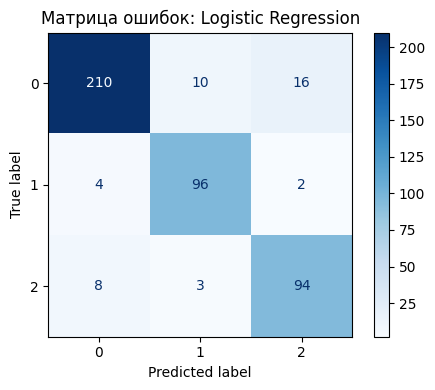

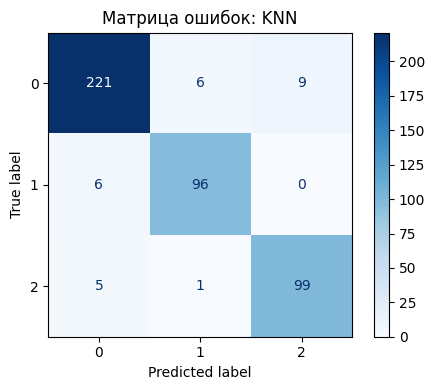

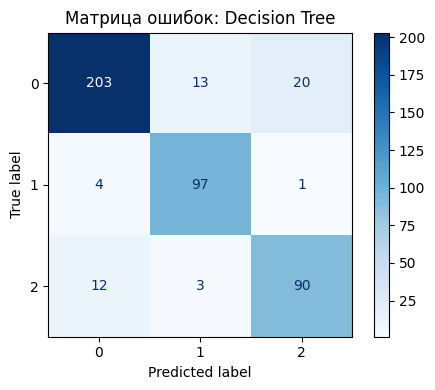

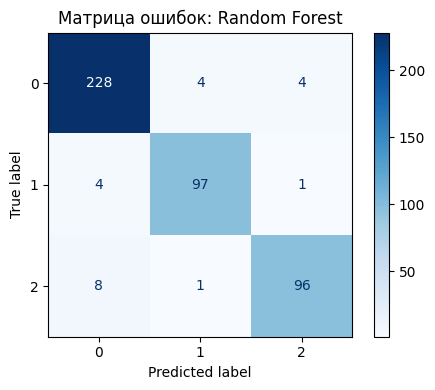

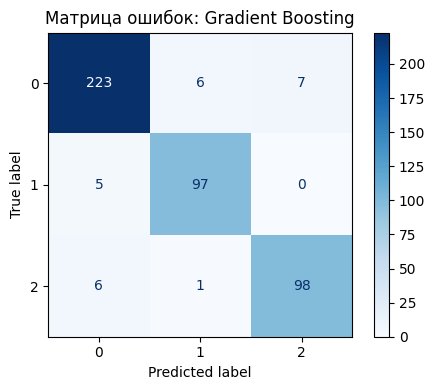

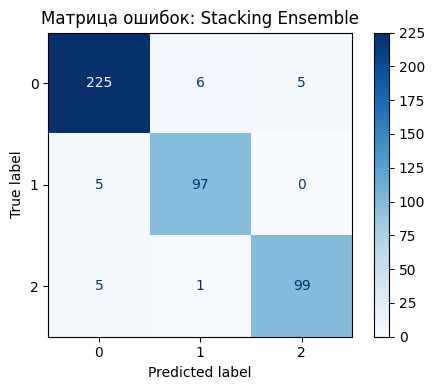

важность признаков

Важность признаков для: Logistic Regression


,Признак,Средний вклад,Стандартное отклонение
1,Children,0.1920,0.0149
8,Share_Wines,0.0923,0.0119
4,PurchaseFrequencyMonthly,0.0759,0.0084
3,TotalSpendToIncome,0.0645,0.0127
5,NumWebVisitsMonth,0.0369,0.0102
9,Share_Meat,0.0337,0.0090
0,Age,0.0337,0.0099
7,StorePurchaseShare,0.0006,0.0033
6,WebPurchaseShare,-0.0065,0.0054
2,Recency,-0.0101,0.0047


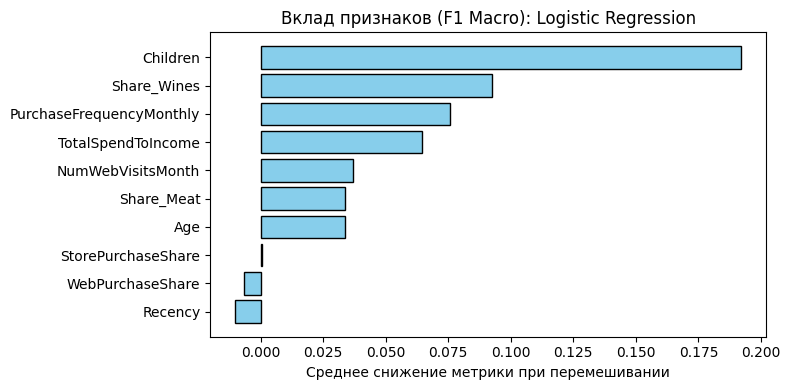


Важность признаков для: KNN


,Признак,Средний вклад,Стандартное отклонение
1,Children,0.2018,0.0164
5,NumWebVisitsMonth,0.1383,0.0145
8,Share_Wines,0.1242,0.0122
4,PurchaseFrequencyMonthly,0.0760,0.0077
0,Age,0.0582,0.0101
9,Share_Meat,0.0341,0.0088
6,WebPurchaseShare,0.0255,0.0075
7,StorePurchaseShare,0.0230,0.0061
2,Recency,0.0208,0.0067
3,TotalSpendToIncome,0.0151,0.0064


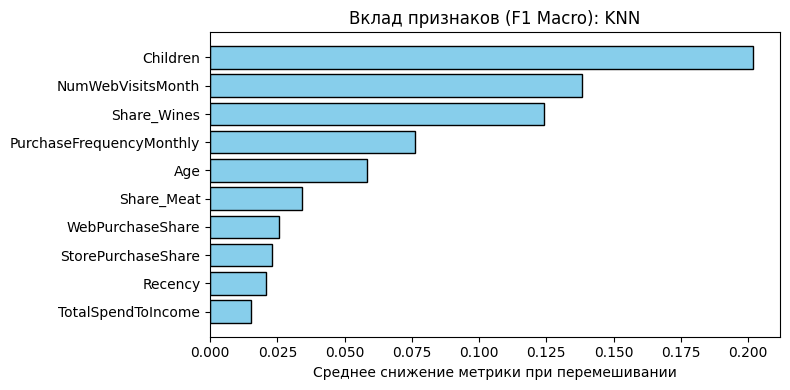


Важность признаков для: Decision Tree


,Признак,Средний вклад,Стандартное отклонение
1,Children,0.2550,0.0246
5,NumWebVisitsMonth,0.1074,0.0112
3,TotalSpendToIncome,0.0980,0.0127
8,Share_Wines,0.0953,0.0106
4,PurchaseFrequencyMonthly,0.0663,0.0093
0,Age,0.0509,0.0070
9,Share_Meat,0.0326,0.0084
6,WebPurchaseShare,0.0118,0.0043
7,StorePurchaseShare,0.0033,0.0021
2,Recency,0.0000,0.0000


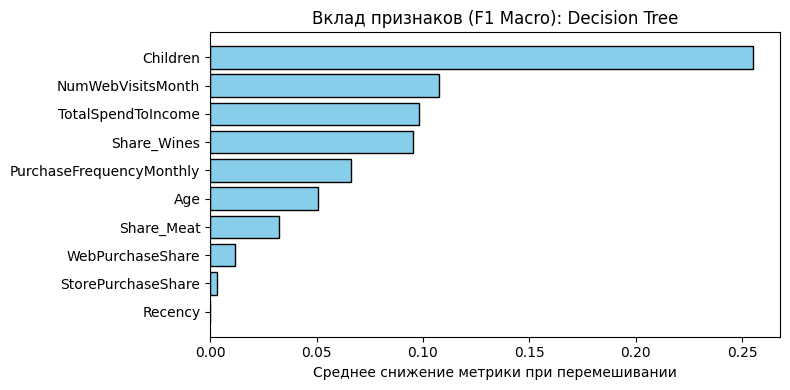


Важность признаков для: Random Forest


,Признак,Средний вклад,Стандартное отклонение
1,Children,0.2342,0.0210
8,Share_Wines,0.1216,0.0132
5,NumWebVisitsMonth,0.1008,0.0130
3,TotalSpendToIncome,0.0714,0.0131
4,PurchaseFrequencyMonthly,0.0676,0.0092
0,Age,0.0465,0.0074
6,WebPurchaseShare,0.0161,0.0056
9,Share_Meat,0.0090,0.0051
7,StorePurchaseShare,0.0030,0.0013
2,Recency,-0.0001,0.0019


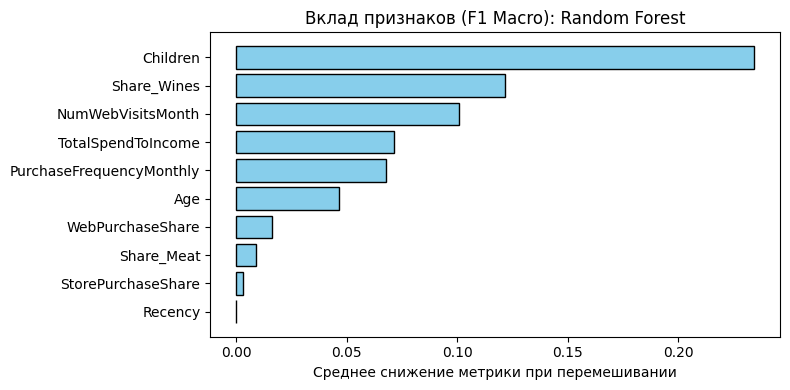


Важность признаков для: Gradient Boosting


,Признак,Средний вклад,Стандартное отклонение
1,Children,0.2286,0.0212
8,Share_Wines,0.1211,0.0133
5,NumWebVisitsMonth,0.0771,0.0106
4,PurchaseFrequencyMonthly,0.0729,0.0108
3,TotalSpendToIncome,0.0653,0.0109
0,Age,0.0411,0.0090
9,Share_Meat,0.0182,0.0063
6,WebPurchaseShare,0.0154,0.0056
7,StorePurchaseShare,0.0109,0.0040
2,Recency,0.0067,0.0038


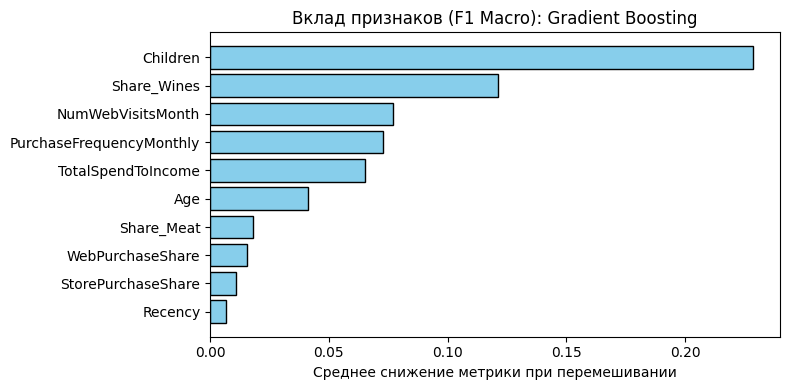


Важность признаков для: Stacking Ensemble


,Признак,Средний вклад,Стандартное отклонение
1,Children,0.2043,0.0178
8,Share_Wines,0.1264,0.0126
5,NumWebVisitsMonth,0.1127,0.0156
4,PurchaseFrequencyMonthly,0.0767,0.0075
0,Age,0.0575,0.0071
3,TotalSpendToIncome,0.0286,0.0063
9,Share_Meat,0.0268,0.0061
7,StorePurchaseShare,0.0225,0.0060
6,WebPurchaseShare,0.0217,0.0066
2,Recency,0.0201,0.0059


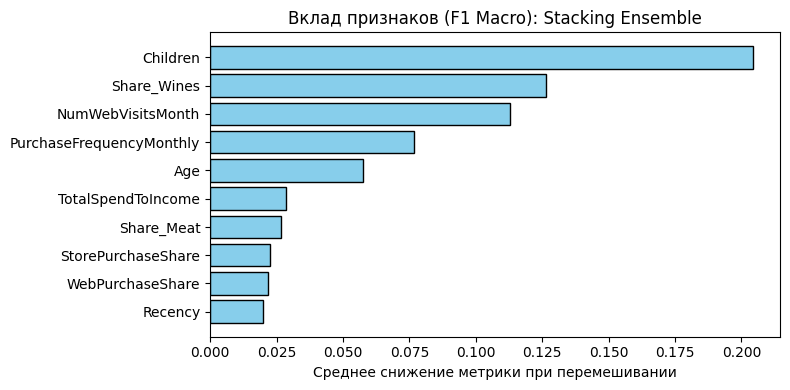

визулазизация древа решений


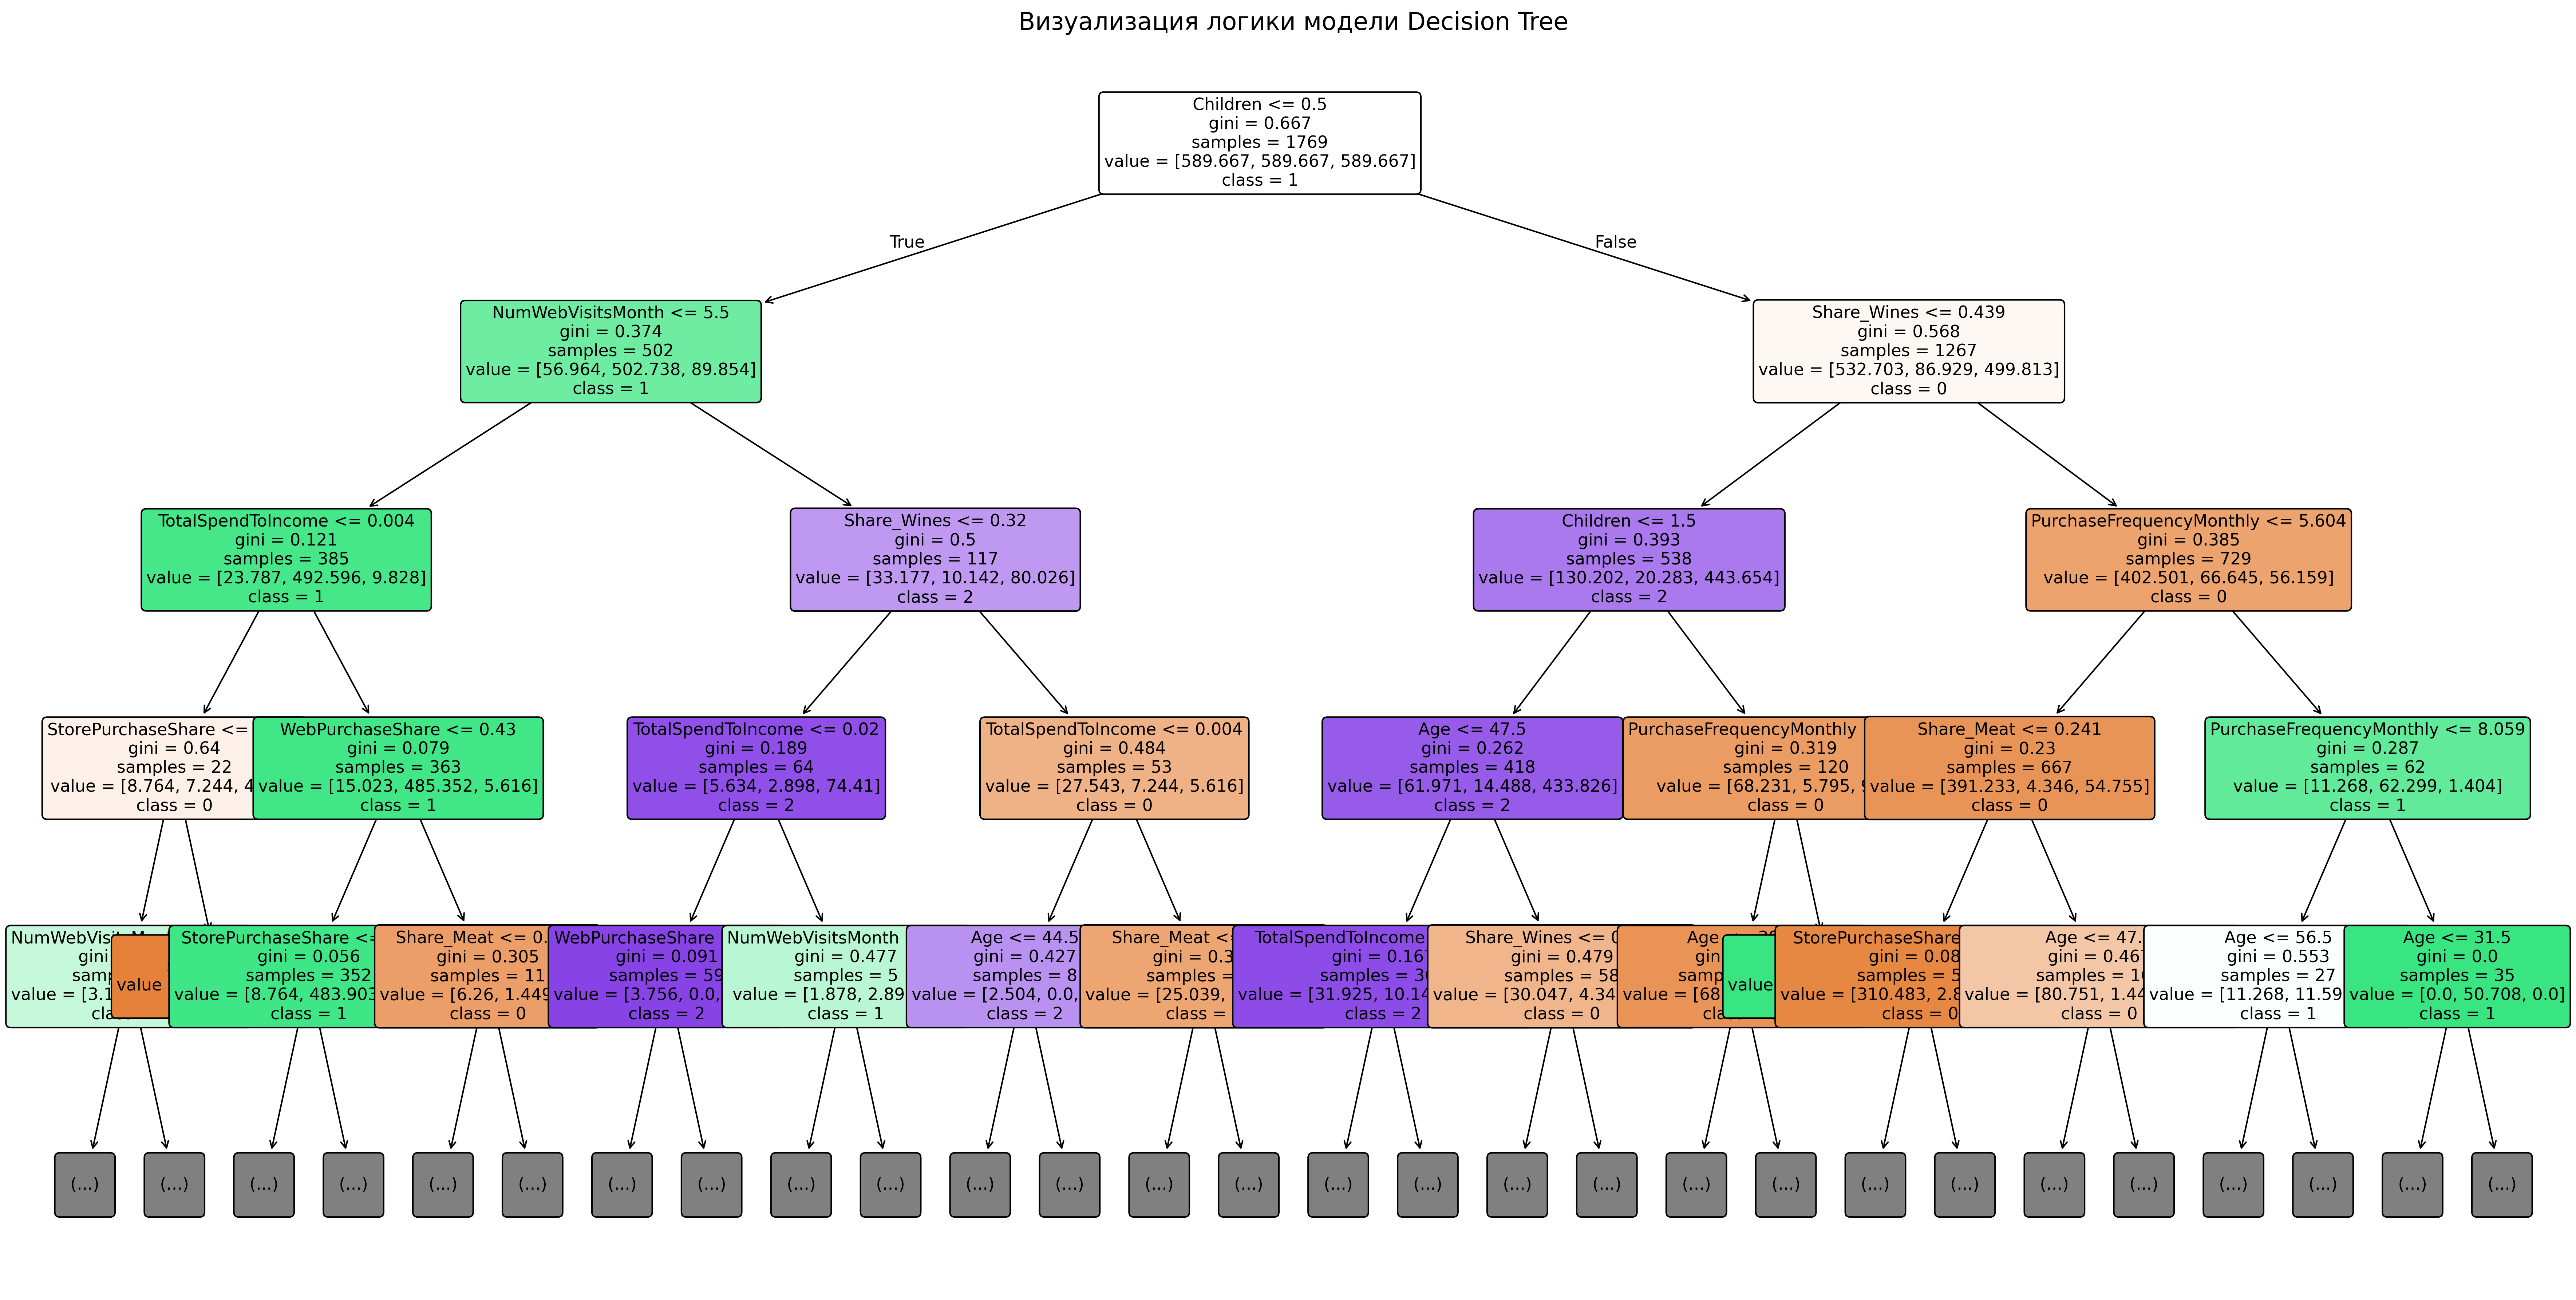

In [30]:

print("Metrics")


results_df = pd.DataFrame(all_results)
numeric_cols = ["Accuracy", "Balanced Accuracy", "F1 Macro", "F1 Weighted"]
results_df[numeric_cols] = results_df[numeric_cols].round(4)
results_df = results_df.sort_values(by="F1 Macro", ascending=False).reset_index(drop=True)
display(results_df)

print("classification reports")

for name, report in classification_reports_tables.items():
    print(f"\nМодель: {name}")
    display(report)



print("confusion matrices")


for name, cm in confusion_matrices.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_multi.unique()))
    plt.figure(figsize=(5, 4))
    disp.plot(values_format="d", cmap="Blues", ax=plt.gca())
    plt.title(f"Матрица ошибок: {name}")
    plt.tight_layout()
    plt.show()



print("важность признаков")


for name, imp_df in feature_importance_tables.items():
    print(f"\nВажность признаков для: {name}")
    display(imp_df)

    plt.figure(figsize=(8, 4))
    plt.barh(imp_df["Признак"], imp_df["Средний вклад"], color="skyblue", edgecolor="black")
    plt.gca().invert_yaxis()
    plt.title(f"Вклад признаков (F1 Macro): {name}")
    plt.xlabel("Среднее снижение метрики при перемешивании")
    plt.tight_layout()
    plt.show()



print("визулазизация древа решений")


tree_model = all_models["Decision Tree"].named_steps["model"]

plt.figure(figsize=(24, 12), dpi=300)
plot_tree(
    tree_model,
    feature_names=features_matrix,
    class_names=[str(c) for c in sorted(y_multi.unique())],
    filled=True,
    rounded=True,
    fontsize=11,
    max_depth=4,
)
plt.title("Визуализация логики модели Decision Tree", fontsize=16)
plt.tight_layout()
plt.show()

In [31]:


print("бинарная классификация (гадалка)")

target_bin = "Response"

df_bin = customers_df.dropna(subset=[*features_matrix, target_bin]).copy()
X_bin = df_bin[features_matrix]
y_bin = df_bin[target_bin].astype(int)

print("\nРаспределение классов для бинарной классификации (Response):")
display(y_bin.value_counts())
print("\nДоли классов:")
display(y_bin.value_counts(normalize=True).round(3))

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin,
    y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin,
)

binary_models = {
    "Logistic Regression (Binary)": Pipeline(
        [("scaler", StandardScaler()), ("model", LogisticRegression(class_weight="balanced", random_state=42))],
    ),
    "Random Forest (Binary)": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
}

бинарная классификация (гадалка)

Распределение классов для бинарной классификации (Response):


Response
0    1879
1     333
Name: count, dtype: int64


Доли классов:


Response
0    0.849
1    0.151
Name: proportion, dtype: float64

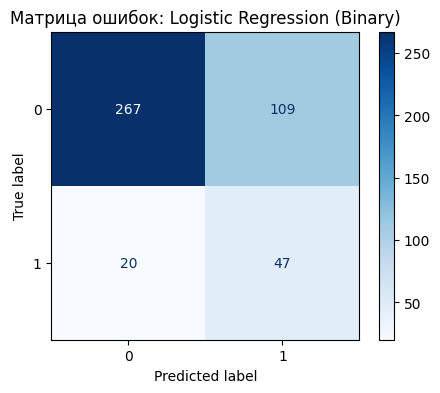

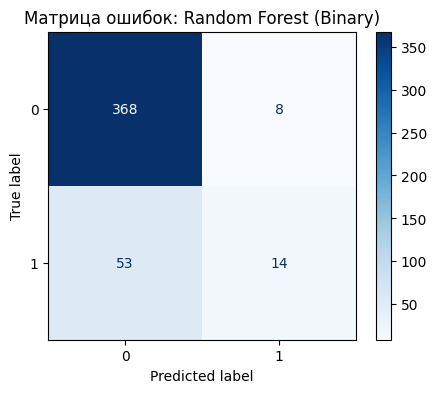

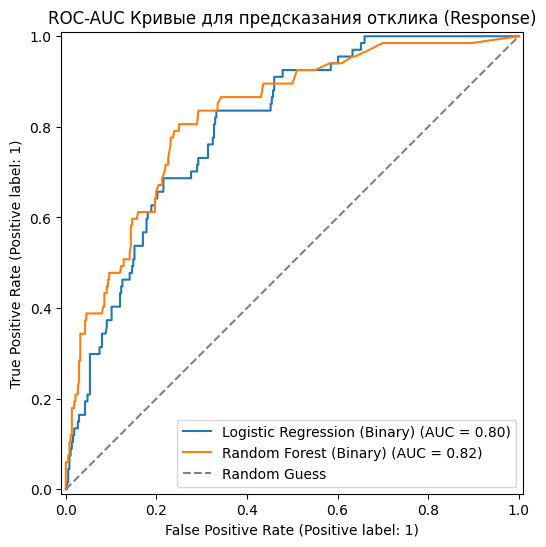


Итоговые метрики бинарной предсказательной аналитики:


,Модель,Accuracy,F1 Score (Binary),ROC-AUC
1,Random Forest (Binary),0.8623,0.3146,0.8242
0,Logistic Regression (Binary),0.7088,0.4215,0.8007


In [ ]:


bin_results = []

for name, model in binary_models.items():
    model.fit(X_train_b, y_train_b)
    y_pred_b = model.predict(X_test_b)
    y_prob_b = model.predict_proba(X_test_b)[:, 1]

    acc = accuracy_score(y_test_b, y_pred_b)
    f1 = f1_score(y_test_b, y_pred_b)
    roc_auc = roc_auc_score(y_test_b, y_prob_b)

    bin_results.append({"Модель": name, "Accuracy": acc, "F1 Score (Binary)": f1, "ROC-AUC": roc_auc})

    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test_b, y_test_b, cmap="Blues", ax=plt.gca())
    plt.title(f"Матрица ошибок: {name}")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for name, model in binary_models.items():
    RocCurveDisplay.from_estimator(model, X_test_b, y_test_b, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC-AUC Кривые для предсказания отклика (Response)")
plt.legend()
plt.show()

bin_results_df = pd.DataFrame(bin_results).round(4).sort_values(by="ROC-AUC", ascending=False)
print("\nИтоговые метрики бинарной предсказательной аналитики:")
display(bin_results_df)